In [34]:
import numpy as np
import matplotlib.pyplot as plt

In [35]:
def ackley(x):
    x = np.asarray(x)
    return - 20 * np.exp(- 0.2 * np.sqrt(np.sum(x ** 2) / len(x))) - np.exp(np.sum(np.cos(2 * np.pi * x)) / len(x)) + 20 + np.e

In [ ]:
class SimpleGA:
    def __init__(self, func, dim, bounds, pop_size=100, generations=200, mutation_rate=0.1, sigma=0.1):
        self.func = func
        self.dim = dim
        self.bounds = bounds
        self.pop_size = pop_size
        self.generations = generations
        self.mutation_rate = mutation_rate
        self.sigma = sigma

    def init_population(self):
        low, high = self.bounds
        return np.random.uniform(low, high, (self.pop_size, self.dim))

    def fitness(self, pop):
        values = np.array([self.func(ind) for ind in pop])
        return 1 / (1 + values), values

    def select(self, pop, fitness):
        probs = fitness / fitness.sum()
        idx = np.random.choice(len(pop), 2, p=probs)
        return pop[idx[0]], pop[idx[1]]

    def crossover(self, p1, p2):
        alpha = np.random.rand(self.dim)
        c1 = alpha * p1 + (1 - alpha) * p2
        c2 = alpha * p2 + (1 - alpha) * p1
        return c1, c2

    def mutate(self, pop):
        mask = np.random.rand(*pop.shape) < self.mutation_rate
        noise = np.random.normal(0, self.sigma, pop.shape)
        pop = pop + mask * noise
        low, high = self.bounds
        return np.clip(pop, low, high)

    def run(self):
        pop = self.init_population()
        best_history = []
        for _ in range(self.generations):
            fit, values = self.fitness(pop)
            best_history.append(values.min())
            children = []
            while len(children) < self.pop_size:
                p1, p2 = self.select(pop, fit)
                c1, c2 = self.crossover(p1, p2)
                children.extend([c1, c2])
            pop = self.mutate(np.array(children[:self.pop_size]))
        return np.array(best_history)

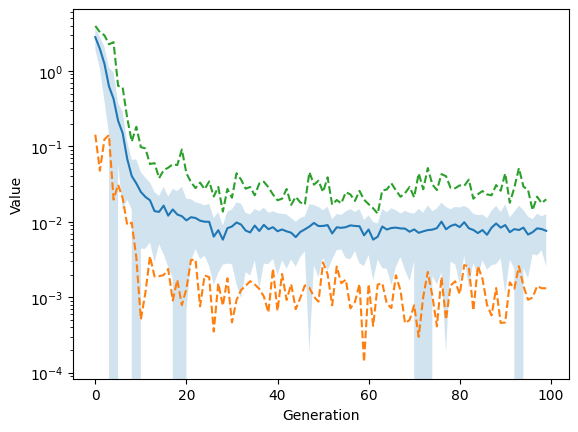

Mean: 0.007610161757052906 Min: 0.0013180001454107249 Max: 0.019957262678318433 Std: 0.0050475254102887385


In [38]:
dim, bounds = 2, (-5, 5)

H = np.array([
    SimpleGA(ackley, dim, bounds, generations=100).run()
    for _ in range(30)
])

m, s = H.mean(0), H.std(0)
mn, mx = H.min(0), H.max(0)

plt.figure()
plt.plot(m)
plt.fill_between(range(100), m - s, m + s, alpha=0.2)
plt.plot(mn, "--")
plt.plot(mx, "--")
plt.yscale("log")
plt.xlabel("Generation")
plt.ylabel("Value")
plt.show()

f = H[:, -1]
print("Mean:", f.mean(), "Min:", f.min(), "Max:", f.max(), "Std:", f.std())